In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('listings - CDMX_clean.xlsx') 
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,1,44616,196253,1,5,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,No neighborhood_overview,Fernando,...,0.0,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,0.41
1,2,67703,334451,2,2,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",No neighborhood_overview,Nicholas,...,4.0,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,0.31
2,3,70644,212109,1,1,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,...,7.0,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.83
3,4,107078,540705,1,1,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,...,0.0,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,0.11
4,5,131610,647454,1,2,previous scrape,MARIA DEL ALMA,No description,No neighborhood_overview,Fernando,...,0.0,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.17


In [3]:
df = df[df['room_type'] == 'Private room']

In [4]:
df['price'] = df['price'].astype(float)

In [7]:
df['host_acceptance_rate'].head(20)

6     0.78
9     1.00
11    0.75
12    0.88
14    1.00
15    0.00
22    1.00
28    0.97
29    0.00
34    1.00
39    0.67
45    0.50
46    0.99
53    1.00
54    0.98
55    0.86
67    0.50
68    0.44
70    0.00
72    0.00
Name: host_acceptance_rate, dtype: float64

In [6]:
df = df[df['host_acceptance_rate'] != 'No data']
df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(float)

C:\Users\issei\AppData\Local\Temp\ipykernel_34324\2668384762.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


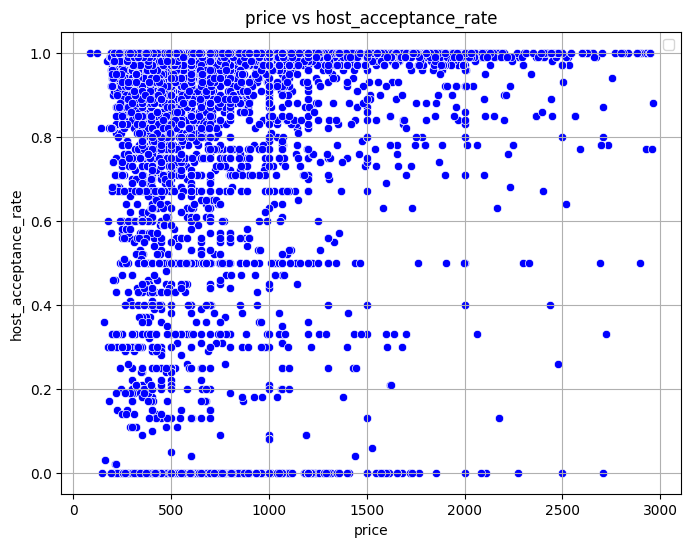

In [8]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='host_acceptance_rate', x='price',  color = 'blue', data=df)
plt.title('price vs host_acceptance_rate')
plt.xlabel('price')
plt.ylabel('host_acceptance_rate')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
indep= df[['host_acceptance_rate']]
dep = df[['price']]

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [11]:
model.fit(indep, dep)

LinearRegression()

In [12]:
type(model)

sklearn.linear_model._base.LinearRegression

In [13]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_acceptance_rate'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[123.35962494]]),
 'rank_': 1,
 'singular_': array([24.87890485]),
 'intercept_': array([609.02024422])}

In [14]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[123.35962494]]
Intercepto: [609.02024422]
y = [123.35962494]x + [609.02024422]


In [15]:
r2 = model.score(indep, dep)
r2

0.00605513776598654

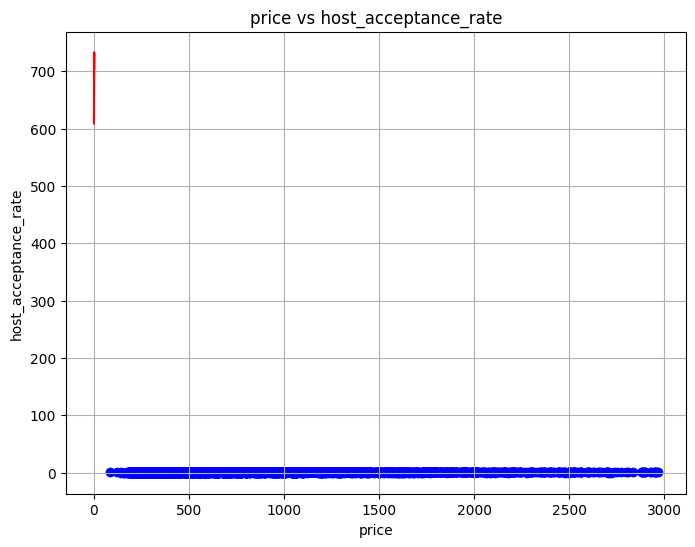

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('price vs host_acceptance_rate')
plt.xlabel('price')
plt.ylabel('host_acceptance_rate')
plt.grid(True)
plt.show()

In [17]:
yPred = model.predict(df[['host_acceptance_rate']])
yPred

array([[705.24075167],
       [732.37986915],
       [701.53996292],
       ...,
       [732.37986915],
       [732.37986915],
       [732.37986915]])

In [18]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones
6,7,171109,816295,1,1,city scrape,Cool room near WTC and Metrobus,"Stay in a private room 2 blocks away from WTC,...","Great location, feel comfortable and secure at...",Carlos,...,0.0,4.84,4.87,4.61,4.98,4.95,4.97,4.81,0.84,705.240752
9,10,1013504,1664327,1,1,city scrape,"OASIS IN COYOACAN, SHARED HOUSE",Private room (single bed) with private bathro...,"Her It's very safe, there are some restaurants...",Edoardo,...,1.0,4.96,4.90,4.92,4.92,4.94,4.92,4.89,0.54,732.379869
11,12,1066945,5870021,1,1,city scrape,"Villa Alfonsina, Heart of Coyoacan",In front of the Frida Kahlo Museum.<br /> Priv...,"Our street ""Allende"" is privileged as it is on...",Héctor,...,0.0,4.93,4.94,4.97,4.96,4.91,4.97,4.94,1.15,701.539963
12,13,1087636,5975456,3,1,city scrape,Apartment at south of Mexico city,No description,No neighborhood_overview,Pamela,...,1.0,4.92,4.86,4.82,4.98,4.96,4.92,4.88,0.41,717.576714
14,15,1167552,6393641,2,1,city scrape,"Big private room with studio, Roma Mexico City.","The Mexican Roma is the place to be, this is a...",Roma Norte has lots to see and enjoy. It´s a v...,José,...,0.0,4.88,4.88,4.62,4.95,4.95,4.95,4.87,1.09,732.379869


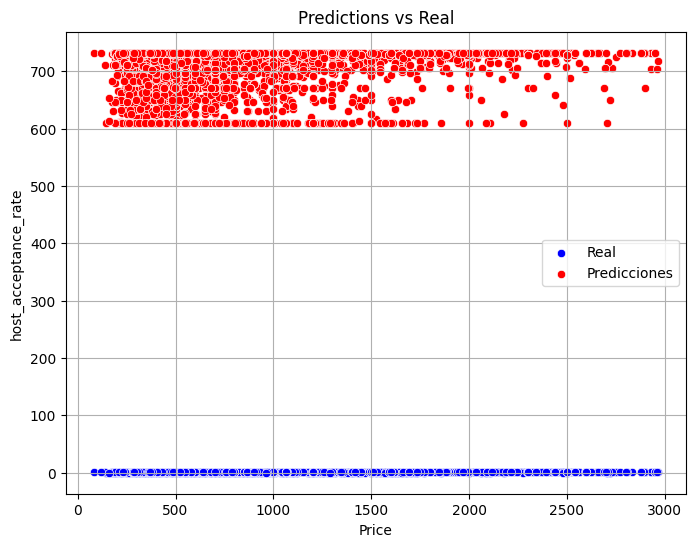

In [19]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='host_acceptance_rate', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('host_acceptance_rate')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
coefDe = model.score(indep, dep)
coefDe

0.00605513776598654

In [21]:
coefCo = np.sqrt(coefDe)
coefCo

0.07781476573238874